In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [3]:
# Only consider the top n features
top_n = 5

In [4]:
# Load the data from Excel
# file_path = "Random Forest Input.xlsx"
# file_path = 'Enhanced Random Forest Input.xlsx'
file_path = 'NonEnsemble-Enhanced Random Forest Input.xlsx'

In [5]:
df = pd.read_excel(file_path)


# Now 'data' contains the DataFrame from the selected file

# Edit the "Patient ID" column to remove everything after the first "_"
df['Patient ID'] = df['Patient ID'].str.split('_').str[0]



In [6]:
sample_len=df.shape[0]
print(sample_len)

16990


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import random

# Preprocess data
# Drop rows with missing target values
df = df.dropna(subset=['Hemorrhage Level'])

# Separate features and target
X = df.drop(columns=['Hemorrhage Level', 'Patient ID'])
y = df['Hemorrhage Level'].astype(str)

# Encode categorical features if necessary
X = pd.get_dummies(X, drop_first=True)  # Convert categorical variables to dummy variables

# Encode target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Custom selection logic for test folders
hemorrhage_10_percent = [
    "ERNE10", "ERNE12", "ERNE23", "ERNE25", "ERNE27", "ERNE32", "ERNE33", "ERNE38", "ERNE39", "ERNE40", 
    "ERNE44", "ERNE48", "ERNE58", "ERNE59", "ERNE61", "ERNE62", "ERNE67", "ERNE70", "ERNE91", "ERNE92", 
    "ERNE93", "ERNE94", "ERNE95", "ERNE96", "ERNE97", "ERNE98", "ERNE99", "ERNE100", "ERNE101", "ERNE102", 
    "ERNE103", "ERNE104", "ERNE105", "ERNE106", "ERNE107", "ERNE108", "ERNE109", "ERNE110", "ERNE111", 
    "ERNE112", "ERNE113", "ERNE114", "ERNE115", "ERNE116", "ERNE117", "ERNE118", "ERNE119", "ERNE120", 
    "ERNE121", "ERNE122", "ERNE123", "ERNE124", "ERNE125", "ERNE126"
]

hemorrhage_20_percent = [
    "ERNE19", "ERNE21", "ERNE30", "ERNE34", "ERNE41", "ERNE45", "ERNE47", "ERNE49", "ERNE50", "ERNE51", 
    "ERNE53", "ERNE54", "ERNE56", "ERNE60", "ERNE63", "ERNE69", "ERNE71", "ERNE72", "ERNE73", "ERNE74", 
    "ERNE75", "ERNE76", "ERNE77", "ERNE78", "ERNE79", "ERNE80", "ERNE81", "ERNE82", "ERNE83", "ERNE84", 
    "ERNE85", "ERNE86", "ERNE87", "ERNE88", "ERNE89", "ERNE90"
]

hemorrhage_30_percent = [
    "ERNE2", "ERNE5", "ERNE7", "ERNE14", "ERNE20", "ERNE26", "ERNE29", "ERNE31", "ERNE35", "ERNE36", 
    "ERNE43", "ERNE52", "ERNE55", "ERNE57", "ERNE64", "ERNE65", "ERNE66", "ERNE68"
]

# Custom parameters for selection
test_amount = 5

# Function to randomly select strings from a given list
def select_random_strings(data_list, number_of_strings):
    return random.sample(data_list, number_of_strings)

# Initialize the lists to store the results
test_folders = []

# Perform the selection for test_folders
selected_10 = select_random_strings(hemorrhage_10_percent, test_amount)
test_folders.extend(selected_10)
hemorrhage_10_percent = [item for item in hemorrhage_10_percent if item not in selected_10]

selected_20 = select_random_strings(hemorrhage_20_percent, test_amount)
test_folders.extend(selected_20)
hemorrhage_20_percent = [item for item in hemorrhage_20_percent if item not in selected_20]

selected_30 = select_random_strings(hemorrhage_30_percent, test_amount)
test_folders.extend(selected_30)
hemorrhage_30_percent = [item for item in hemorrhage_30_percent if item not in selected_30]

# Display selected test folders
print("Test Folders:", test_folders)

# Split the data based on custom logic
train_indices = df[~df['Patient ID'].isin(test_folders)].index
test_indices = df[df['Patient ID'].isin(test_folders)].index

# Use custom indices to create train and test sets
X_train, X_test = X.loc[train_indices], X.loc[test_indices]
y_train, y_test = y[train_indices], y[test_indices]


Test Folders: ['ERNE117', 'ERNE107', 'ERNE96', 'ERNE106', 'ERNE70', 'ERNE21', 'ERNE19', 'ERNE49', 'ERNE72', 'ERNE85', 'ERNE52', 'ERNE2', 'ERNE68', 'ERNE64', 'ERNE31']


In [8]:

# # Train a Decision Tree Classifier
# clf = DecisionTreeClassifier(random_state=42)
# clf.fit(X_train, y_train)

# # Evaluate the model
# accuracy = clf.score(X_test, y_test)
# print(f"Test Accuracy: {accuracy:.2f}")


In [9]:


# Class balancing with SMOTE on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Calculate the size of the smallest class in the test set
counter = Counter(y_test)
min_class_size = min(counter.values())

# Drop elements from overrepresented classes in the test set
X_test_balanced = pd.DataFrame()
y_test_balanced = []
for cls, count in counter.items():
    indices = np.where(y_test == cls)[0]
    if count > min_class_size:
        drop_indices = np.random.choice(indices, size=count - min_class_size, replace=False)
        X_test_balanced = pd.concat([X_test_balanced, X_test.drop(X_test.index[drop_indices]).reset_index(drop=True)])
        y_test_balanced.extend(y_test[np.isin(np.arange(len(y_test)), np.setdiff1d(np.arange(len(y_test)), drop_indices))])
    else:
        X_test_balanced = pd.concat([X_test_balanced, X_test.iloc[indices]])
        y_test_balanced.extend(y_test[indices])

# Convert y_test_balanced to numpy array
y_test_balanced = np.array(y_test_balanced)

# Trim to the size of the smallest class
counter_balanced = Counter(y_test_balanced)
min_class_size_balanced = min(counter_balanced.values())

# Ensure close to the minimum class size samples per class in the test set
X_test_balanced_trimmed = pd.DataFrame()
y_test_balanced_trimmed = []
desired_class_size = min(min(sample_len/4, min_class_size_balanced), min_class_size)  # Example: Close to 4 samples per class or the minimum class size

for cls, count in counter_balanced.items():
    indices = np.where(y_test_balanced == cls)[0]
    np.random.shuffle(indices)  # shuffle indices
    keep_indices = indices[:min(desired_class_size, count)]  # keep up to desired_class_size samples or less if count < desired_class_size
    X_test_balanced_trimmed = pd.concat([X_test_balanced_trimmed, X_test_balanced.iloc[keep_indices]])
    y_test_balanced_trimmed.extend(y_test_balanced[keep_indices])

# Convert y_test_balanced_trimmed to numpy array
y_test_balanced_trimmed = np.array(y_test_balanced_trimmed)

/Users/fahizzle/ml-env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [10]:

# Train a Decision Tree Classifier with hyperparameters
clf = DecisionTreeClassifier(
    criterion='gini',  # or 'entropy'
    splitter='best',   # or 'random'
    max_depth=top_n,    # or any integer value
    min_samples_split=2,  # or any integer value
    min_samples_leaf=1,  # or any integer value
    max_features=None,  # or 'auto', 'sqrt', 'log2'
    random_state=42
)

clf.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred = clf.predict(X_test_balanced_trimmed)

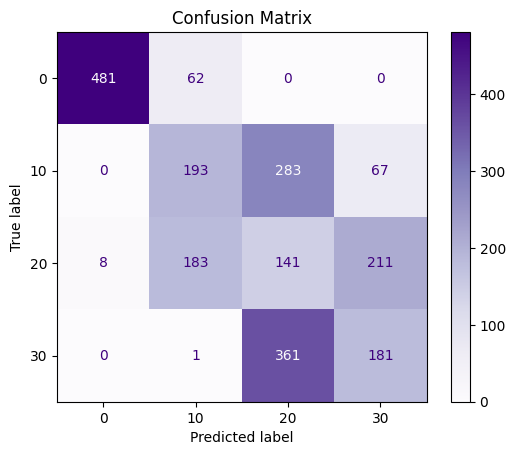

Accuracy: 0.4585635359116022


In [11]:

# Evaluate the model
# Confusion Matrix
cm = confusion_matrix(y_test_balanced_trimmed, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix")
plt.show()

# Accuracy
accuracy = accuracy_score(y_test_balanced_trimmed, y_pred)
print(f"Accuracy: {accuracy}")



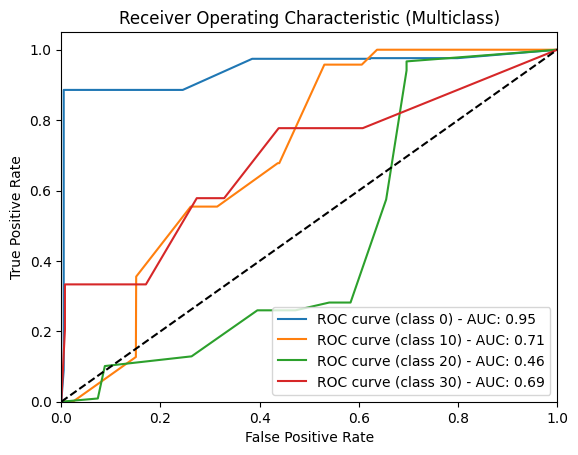

In [12]:
# # ROC Curve for multiclass
# y_test_binarized = label_binarize(y_test_balanced_trimmed, classes=np.unique(y))
# y_pred_proba = clf.predict_proba(X_test_balanced_trimmed)

# plt.figure()
# for i in range(y_test_binarized.shape[1]):
#     fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
#     plt.plot(fpr, tpr, label=f'ROC curve (class {label_encoder.classes_[i]})')

# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (Multiclass)')
# plt.legend(loc='lower right')
# plt.show()

from sklearn.metrics import auc

# ROC Curve for multiclass with AUC
y_test_binarized = label_binarize(y_test_balanced_trimmed, classes=np.unique(y))
y_pred_proba = clf.predict_proba(X_test_balanced_trimmed)

plt.figure()
for i in range(y_test_binarized.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (class {label_encoder.classes_[i]}) - AUC: {roc_auc:.2f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Multiclass)')
plt.legend(loc='lower right')
plt.show()

In [13]:
# # F1 Score
# f1 = f1_score(y_test_balanced_trimmed, y_pred, average='weighted')
# print(f"F1 Score: {f1:.2f}")

from sklearn.metrics import f1_score, classification_report

# Calculate F1 Scores
f1_scores = f1_score(y_test_balanced_trimmed, y_pred, average=None)
print("\nF1 Scores per Class:\n")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"F1 Score for class '{class_name}': {f1_scores[i]:.4f}")



F1 Scores per Class:

F1 Score for class '0': 0.9322
F1 Score for class '10': 0.3931
F1 Score for class '20': 0.2123
F1 Score for class '30': 0.3613


In [14]:
# Convert the class labels to strings
class_names = list(map(str, label_encoder.classes_))


# Plot the Decision Tree
# plt.figure(figsize=(20, 10))
plt.figure(figsize=(30, 10), dpi=600)
plot_tree(clf, 
          filled=True, 
          feature_names=X.columns.tolist(), 
          class_names=class_names,  # Pass the class names as strings
          rounded=True)

# Save the Decision Tree as an image file
output_image_path = "decision_tree_visualization.png"
plt.savefig(output_image_path, bbox_inches='tight')
plt.close()

print(f"Decision tree image saved as {output_image_path}")

Decision tree image saved as decision_tree_visualization.png


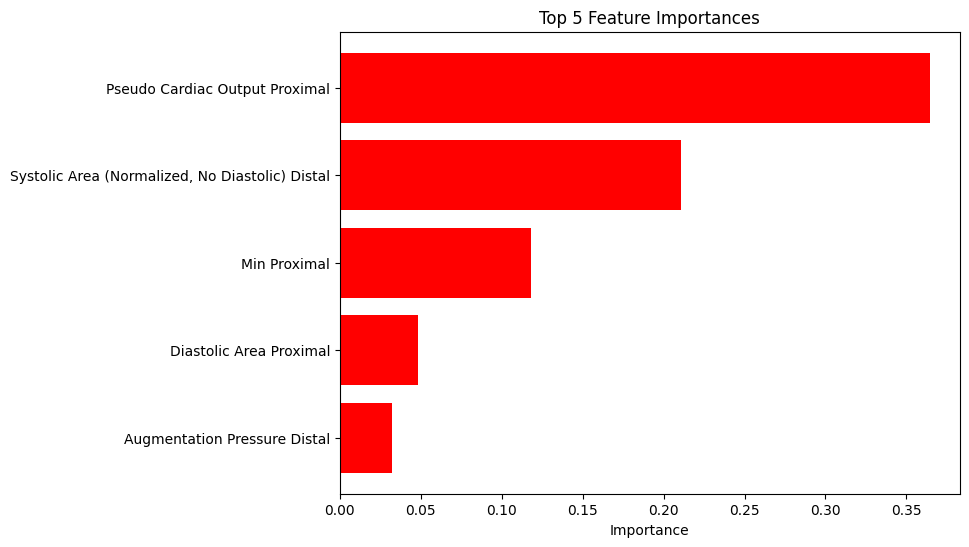

In [15]:
# # Plot Feature Importance
# importances = clf.feature_importances_
# indices = np.argsort(importances)[::-1]  # Sort in descending order

# plt.figure(figsize=(12, 8))
# plt.title("Feature Importance")
# plt.bar(range(X.shape[1]), importances[indices], align='center')
# plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
# plt.xlim([-1, X.shape[1]])
# plt.tight_layout()


# Plot Feature Importances (Horizontal Bar Plot for Top 10 Features)
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort in descending order

top_indices = indices[:top_n]

plt.figure(figsize=(8, 6))
plt.title(f"Top {top_n} Feature Importances")
plt.barh(range(top_n), importances[top_indices], color="r", align="center")
plt.yticks(range(top_n), X.columns[top_indices])
plt.xlabel("Importance")
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.show()

In [16]:
# Print out the names of the top 20 features
print(f"Top {top_n} Features:")
for feature in X.columns[top_indices]:
    print(feature)


Top 5 Features:
Pseudo Cardiac Output Proximal
Systolic Area (Normalized, No Diastolic) Distal
Min Proximal
Diastolic Area Proximal
Augmentation Pressure Distal


In [20]:
import os
import pydotplus
from sklearn.tree import export_graphviz

# Ensure the directory exists
os.makedirs("Tree Branches-DT", exist_ok=True)

# Use the same feature names used for training
feature_names = X.columns.tolist()

dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=feature_names,
    class_names=[str(cls) for cls in label_encoder.classes_],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png("Tree Branches-DT/tree.png")

print("Decision tree saved in the 'Tree Branches-DT' folder.")

Decision tree saved in the 'Tree Branches-DT' folder.
